# Pre-processing Pipeline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from collections import Counter
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import json

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Helper functions for data collection
from scripts.collect_helper import check_cluster, pull_logs, get_collection_stats

## Connect to K8s cluster & Get all pods

In [2]:
check_cluster()

  Cluster Info

Total Nodes:
NAME              STATUS   ROLES           AGE   VERSION
217.216.110.115   Ready    worker          23d   v1.30.14
217.217.255.103   Ready    control-plane   23d   v1.30.14

Benign Pods:
NAME                                READY   STATUS      RESTARTS          AGE
flask-postgres-7f55b7f765-88rzs     1/1     Running     0                 9d
flask-todo-5776c4b694-hp2hm         1/1     Running     1 (9d ago)        9d
flask-todo-5776c4b694-p2drl         1/1     Running     1 (9d ago)        9d
mariadb-sysbench-6c4fb7967d-wr9wr   1/1     Running     0                 9d
media-streaming-5c9d5598b5-jdh6j    1/1     Running     0                 9d
memcached-server-6d67479f7b-gsnbq   1/1     Running     0                 9d
stimulator-db-1778600636            0/1     Completed   0                 11h
stimulator-flask-1777433126         0/1     Completed   0                 13d
stimulator-flask-1778248051         0/1     Completed   0                 4d13h
stimulat

True

## Data Collection

Pull logs from Cilium dan Tetragon

In [3]:
pull_logs(sessions=60, interval=300, stimulate=True)
get_collection_stats()

  K-IDS Multi-Session Data Collection
  Sessions : 60
  Interval : 300s (5 min)
  Stimulate: True
  Est. time: ~295 minutes

Running: bash /mnt/nvme0n1p11/Github/project-kIDS/feature_engineering/scripts/collect_data.sh --sessions 60 --interval 300 --stimulate


 K-IDS Multi-Session Data Collector

  Sessions  : 60
  Interval  : 300s
  Stimulate : true
  Output    : /mnt/nvme0n1p11/Github/project-kIDS/feature_engineering/raw_logs

[STEP]  23:00:19 Running pre-flight checks...
[INFO]  23:00:20 Cluster connection: OK
[INFO]  23:00:20 Tetragon pods: 2
[INFO]  23:00:21 Cilium pods: 2

[STEP]  23:00:21 Workload status:
  Benign workloads:
    flask-postgres-7f55b7f765-88rzs     1/1   Running     0               9d
    flask-todo-5776c4b694-hp2hm         1/1   Running     1 (9d ago)      9d
    flask-todo-5776c4b694-p2drl         1/1   Running     1 (9d ago)      9d
    mariadb-sysbench-6c4fb7967d-wr9wr   1/1   Running     0               9d
    media-streaming-5c9d5598b5-jdh6j    1/1   Runni

In [3]:
with open("raw_logs/hubble.json") as f:
    hubble_malicious = [json.loads(line) for line in f if line.strip() and "malicious-containers-stratus" in line.lower()][:2]

print(f"Hubble malicious:")
print(json.dumps(hubble_malicious, indent=1))

Hubble malicious:
[
 {
  "flow": {
   "time": "2026-05-12T16:01:24.297995091Z",
   "uuid": "31cb5f26-ce24-48cc-ac57-4ad9d326cda3",
   "emitter": {
    "name": "Hubble",
    "version": "1.19.2+g3977f6a1"
   },
   "verdict": "TRACED",
   "IP": {
    "source": "10.42.1.28",
    "destination": "10.43.0.1",
    "ipVersion": "IPv4"
   },
   "l4": {
    "TCP": {
     "destination_port": 443
    }
   },
   "source": {
    "ID": 638,
    "identity": 10434,
    "cluster_name": "default",
    "namespace": "malicious",
    "labels": [
     "k8s:app.kubernetes.io/component=stratus-attacker",
     "k8s:app.kubernetes.io/instance=malicious",
     "k8s:app.kubernetes.io/name=malicious-containers",
     "k8s:io.cilium.k8s.namespace.labels.kubernetes.io/metadata.name=malicious",
     "k8s:io.cilium.k8s.policy.cluster=default",
     "k8s:io.cilium.k8s.policy.serviceaccount=stratus-attacker",
     "k8s:io.kubernetes.pod.namespace=malicious",
     "k8s:kids-label=1"
    ],
    "pod_name": "malicious-contai

In [4]:
with open("raw_logs/tetragon.json") as f:
    tetragon_socket = [json.loads(line) for line in f if line.strip() and "malicious-containers-stratus" in line.lower()][:2]
print(f"\nTetragon socket:")
print(json.dumps(tetragon_socket, indent=1))


Tetragon socket:
[
 {
  "process_exit": {
   "process": {
    "exec_id": "MjE3LjIxNi4xMTAuMTE1OjE4NjY1MDkzNjA1OTU1ODg6MjQ0MzQwOQ==",
    "pid": 2443409,
    "uid": 0,
    "cwd": "/tmp/stratus-tf-version-check3601451069",
    "binary": "/root/.stratus-red-team/terraform",
    "arguments": "version -json",
    "flags": "execve clone inInitTree",
    "start_time": "2026-05-12T16:52:47.385731736Z",
    "auid": 4294967295,
    "pod": {
     "namespace": "malicious",
     "name": "malicious-containers-stratus-7f9675cd4-sc6w5",
     "uid": "e6f3fd69-e4c9-4cdf-a8e4-cdbde04f8506",
     "container": {
      "id": "containerd://a92edbd2ef9752b6768f4a3805cbf390abc37bee4761963fc49c5b2cc8a67f32",
      "name": "stratus",
      "image": {
       "id": "docker.io/library/alpine@sha256:5b10f432ef3da1b8d4c7eb6c487f2f5a8f096bc91145e68878dd4a5019afde11",
       "name": "docker.io/library/alpine:latest"
      },
      "start_time": "2026-05-09T04:22:34Z",
      "pid": 167088,
      "security_context": {}


In [3]:
"""Labeling using binary classification"""
LABEL_MAP = {
    # Malicious labels
    "mirai": 1,
    "kinsing": 1,
    "teamtnt": 1,
    "stratus": 1,
    "agent": 1,
    "coinminer": 1,
    "miner": 1,
    
    # Benign labels
    "mariadb": 0,
    "postgres": 0,
    "mysql": 0,
    "media-streaming": 0,
    "memcached": 0,
    "web-serving": 0,
    "flask": 0,        
    "wordpress": 0,
    "sysbench": 0,
    "stimulator": 0,    
    "backend-api": 0,
    "frontend": 0     
}

def get_label(pod_name):
    pod_lower = pod_name.lower() if pod_name else ''
    for key, label in LABEL_MAP.items():
        if key in pod_lower:
            return label
    return -1

print(f"Label mapping: {len([v for v in LABEL_MAP.values() if v == 0])} benign, {len([v for v in LABEL_MAP.values() if v == 1])} malicious")

Label mapping: 12 benign, 7 malicious


## 2. Parse Tetragon (Syscall) - Per Pod 5-grams

In [4]:
def parse_tetragon(filepath):
    records = []
    
    with open(filepath) as f:
        for line in f:
            if not line.strip():
                continue
            try:
                entry = json.loads(line)
                
                if 'process_exec' in entry:
                    proc = entry['process_exec']['process']
                    pod = proc.get('pod', {})
                    records.append({
                        'pod_name': pod.get('name', ''),
                        'syscall': 'execve',
                        'label': get_label(pod.get('name', ''))
                    })
                
                elif 'process_exit' in entry:
                    proc = entry['process_exit']['process']
                    pod = proc.get('pod', {})
                    records.append({
                        'pod_name': pod.get('name', ''),
                        'syscall': 'exit',
                        'label': get_label(pod.get('name', ''))
                    })
                    
            except:
                continue
    
    df = pd.DataFrame(records)
    print(f"✓ Parsed {len(df):,} Tetragon events")
    print(f"  Labels: {df['label'].value_counts().to_dict()}")
    return df

tetragon_df = parse_tetragon('raw_logs/tetragon.json')

✓ Parsed 75,599 Tetragon events
  Labels: {0: 53434, 1: 22155, -1: 10}


In [5]:
# Convert Syscall name to number
SYSCALL_MAP = {
    'read': 0, 'write': 1, 'open': 2, 'close': 3, 'stat': 4, 'fstat': 5,
    'mmap': 9, 'socket': 41, 'connect': 42, 'accept': 43, 'clone': 56,
    'fork': 57, 'execve': 59, 'exit': 60, 'kill': 62, 'openat': 257
}

tetragon_df['syscall_num'] = tetragon_df['syscall'].apply(lambda x: SYSCALL_MAP.get(x, -1))

# Generate 5-grams per pod
def generate_ngrams(sequence, n=5):
    return [tuple(sequence[i:i+n]) for i in range(len(sequence) - n + 1)]

syscall_seqs = tetragon_df.groupby(['pod_name', 'label'])['syscall_num'].apply(list).reset_index()
syscall_seqs.columns = ['pod_name', 'label', 'sequence']
syscall_seqs['ngrams'] = syscall_seqs['sequence'].apply(lambda x: generate_ngrams(x, 5))

# Flatten
ngram_records = []
for _, row in syscall_seqs.iterrows():
    for ngram in row['ngrams']:
        ngram_records.append({
            'pod_name': row['pod_name'],
            'label': row['label'],
            'n1': ngram[0], 'n2': ngram[1], 'n3': ngram[2], 'n4': ngram[3], 'n5': ngram[4]
        })

syscall_dataset = pd.DataFrame(ngram_records)
syscall_dataset = syscall_dataset[syscall_dataset['label'] >= 0]

print(f"✓ Syscall: {len(syscall_dataset):,} 5-grams")
print(f"  Labels: {syscall_dataset['label'].value_counts().to_dict()}")

✓ Syscall: 74,309 5-grams
  Labels: {0: 52170, 1: 22139}


## 3. Parse Hubble (Network) - Per Flow Features

In [6]:
def parse_hubble(filepath):
    records = []
    
    with open(filepath) as f:
        for line in f:
            if not line.strip():
                continue
            try:
                entry = json.loads(line)
                if 'flow' not in entry:
                    continue
                
                flow = entry['flow']
                src = flow.get('source', {})
                dst = flow.get('destination', {})
                l4 = flow.get('l4', {})
                tcp = l4.get('TCP', {})
                udp = l4.get('UDP', {})
                flags = tcp.get('flags', {})
                
                # Get pod from source or destination
                pod_name = src.get('pod_name') or dst.get('pod_name', '')
                if not pod_name:
                    continue
                
                label = get_label(pod_name)
                if label < 0:  # Skip unknown
                    continue
                
                records.append({
                    'pod_name': pod_name,
                    'label': label,
                    # Protocol
                    'proto_TCP': 1 if tcp else 0,
                    'proto_UDP': 1 if udp else 0,
                    # Traffic direction
                    'dir_EGRESS': 1 if flow.get('traffic_direction') == 'EGRESS' else 0,
                    'dir_INGRESS': 1 if flow.get('traffic_direction') == 'INGRESS' else 0,
                    # Verdict
                    'verdict_FORWARDED': 1 if flow.get('verdict') == 'FORWARDED' else 0,
                    'verdict_TRACED': 1 if flow.get('verdict') == 'TRACED' else 0,
                    # TCP Flags
                    'flag_SYN': int(flags.get('SYN', False)),
                    'flag_ACK': int(flags.get('ACK', False)),
                    'flag_FIN': int(flags.get('FIN', False)),
                    'flag_RST': int(flags.get('RST', False)),
                    'flag_PSH': int(flags.get('PSH', False)),
                    # Other
                    'is_reply': int(flow.get('is_reply', False))
                })
            except:
                continue
    
    df = pd.DataFrame(records)
    print(f"✓ Parsed {len(df):,} Hubble flows (per-flow, not aggregated)")
    print(f"  Labels: {df['label'].value_counts().to_dict()}")
    return df

network_dataset = parse_hubble('raw_logs/hubble.json')
network_dataset.head()

✓ Parsed 128,086 Hubble flows (per-flow, not aggregated)
  Labels: {0: 121992, 1: 6094}


,pod_name,label,proto_TCP,proto_UDP,dir_EGRESS,dir_INGRESS,verdict_FORWARDED,verdict_TRACED,flag_SYN,flag_ACK,flag_FIN,flag_RST,flag_PSH,is_reply
0,stimulator-wp-1778601624,0,0,1,1,0,1,0,0,0,0,0,0,0
1,stimulator-wp-1778601624,0,0,1,1,0,1,0,0,0,0,0,0,0
2,stimulator-wp-1778601624,0,1,0,1,0,1,0,1,0,0,0,0,0
3,wordpress-app-7bdc697847-lsblm,0,1,0,1,0,1,0,1,1,0,0,0,1
4,stimulator-wp-1778601624,0,1,0,1,0,1,0,0,1,0,0,0,0


## 4. Feature Selection (Network)

SelectKBest k=20 dengan chi-squared

Features after removing dest_port: 12
Features after removing zero-variance: 11

✓ Selected top 11 features:
  flag_RST: 16895.51
  flag_ACK: 520.12
  proto_UDP: 486.61
  flag_PSH: 252.28
  flag_FIN: 248.03
  flag_SYN: 180.06
  verdict_TRACED: 93.51
  proto_TCP: 90.24
  is_reply: 5.81
  dir_EGRESS: 0.20


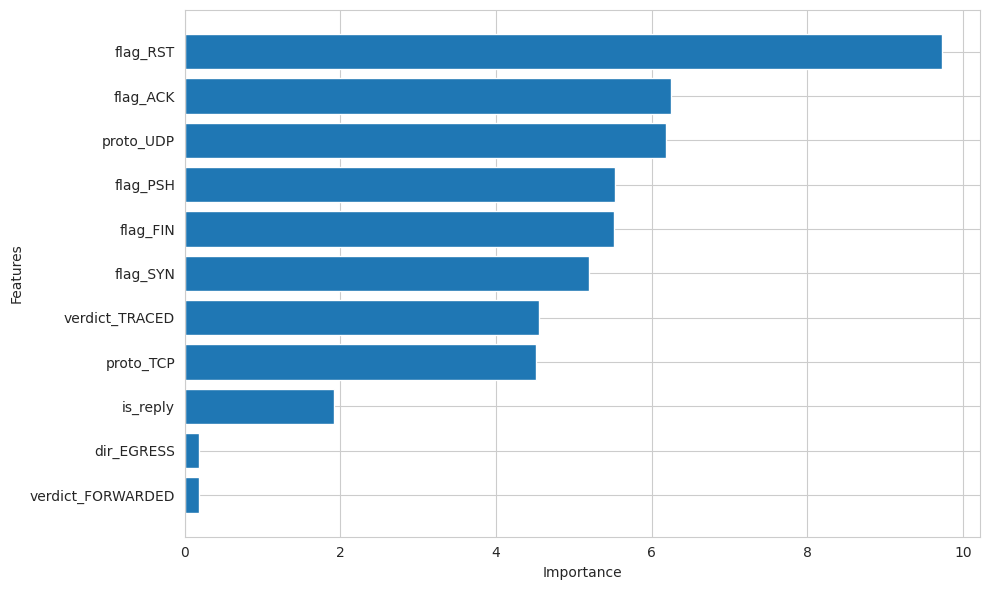

In [14]:
X_flow = network_dataset.drop(columns=['pod_name', 'label'])
y_flow = network_dataset['label']

# Handle missing values
X_flow = X_flow.fillna(0)

# Remove dest_port to prevent label leakage (as per paper)
X_flow = X_flow.drop(columns=['dest_port'], errors='ignore')
print(f"Features after removing dest_port: {len(X_flow.columns)}")

# Remove zero-variance features
variance = X_flow.var()
non_zero_cols = variance[variance > 0].index.tolist()
X_flow = X_flow[non_zero_cols]

print(f"Features after removing zero-variance: {len(non_zero_cols)}")

# SelectKBest
k = min(20, len(non_zero_cols))
selector = SelectKBest(chi2, k=k)
X_flow_selected = selector.fit_transform(X_flow.abs(), y_flow)

selected_features = X_flow.columns[selector.get_support()].tolist()
scores = selector.scores_[selector.get_support()]

print(f"\n✓ Selected top {k} features:")
for feat, score in sorted(zip(selected_features, scores), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {feat}: {score:.2f}")

# Plot
plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(scores)
plt.barh([selected_features[i] for i in sorted_idx], np.log1p(scores[sorted_idx]))
plt.xlabel('Importance')
plt.ylabel('Features')
# plt.title('Top Network Flow Features')
plt.tight_layout()
plt.savefig('output/network_feature_importance.png', dpi=150)
plt.show()

## 5. Train/Test Split

In [13]:
# Syscall
X_syscall = syscall_dataset[['n1', 'n2', 'n3', 'n4', 'n5']]
y_syscall = syscall_dataset['label']

X_train_sys, X_test_sys, y_train_sys, y_test_sys = train_test_split(
    X_syscall, y_syscall, test_size=0.3, random_state=42, stratify=y_syscall
)

print("=== Syscall Dataset ===")
print(f"Train: {len(X_train_sys):,} | Test: {len(X_test_sys):,}")
print(f"Train labels: {Counter(y_train_sys)}")
print(f"Test labels: {Counter(y_test_sys)}")

# Network
X_train_flow, X_test_flow, y_train_flow, y_test_flow = train_test_split(
    X_flow_selected, y_flow, test_size=0.3, random_state=42, stratify=y_flow
)

print("\n=== Network Flow Dataset ===")
print(f"Train: {len(X_train_flow):,} | Test: {len(X_test_flow):,}")
print(f"Train labels: {Counter(y_train_flow)}")
print(f"Test labels: {Counter(y_test_flow)}")

=== Syscall Dataset ===
Train: 52,016 | Test: 22,293
Train labels: Counter({0: 36519, 1: 15497})
Test labels: Counter({0: 15651, 1: 6642})

=== Network Flow Dataset ===
Train: 89,660 | Test: 38,426
Train labels: Counter({0: 85394, 1: 4266})
Test labels: Counter({0: 36598, 1: 1828})


## 6. Save Datasets

In [9]:
# Syscall
syscall_dataset.to_csv('dataset/syscall_dataset.csv', index=False)
print(f"✓ Saved syscall_dataset.csv ({len(syscall_dataset):,} rows)")

# Network
flow_df_selected = pd.DataFrame(X_flow_selected, columns=selected_features)
flow_df_selected['label'] = y_flow.values
flow_df_selected.to_csv('dataset/network_flow_dataset.csv', index=False)
print(f"✓ Saved network_flow_dataset.csv ({len(flow_df_selected):,} rows)")

# Artifacts
joblib.dump(selector, 'dataset/feature_selector.pkl')
joblib.dump(selected_features, 'dataset/selected_features.pkl')

print(f"\n=== Summary ===")
print(f"Syscall: {len(syscall_dataset):,} 5-grams | Labels: {Counter(syscall_dataset['label'])}")
print(f"Network: {len(flow_df_selected):,} flows | Labels: {Counter(y_flow)}")
print(f"Selected features: {selected_features}")

✓ Saved syscall_dataset.csv (74,309 rows)
✓ Saved network_flow_dataset.csv (128,086 rows)

=== Summary ===
Syscall: 74,309 5-grams | Labels: Counter({0: 52170, 1: 22139})
Network: 128,086 flows | Labels: Counter({0: 121992, 1: 6094})
Selected features: ['proto_TCP', 'proto_UDP', 'dir_EGRESS', 'verdict_FORWARDED', 'verdict_TRACED', 'flag_SYN', 'flag_ACK', 'flag_FIN', 'flag_RST', 'flag_PSH', 'is_reply']


## 7. Visualization

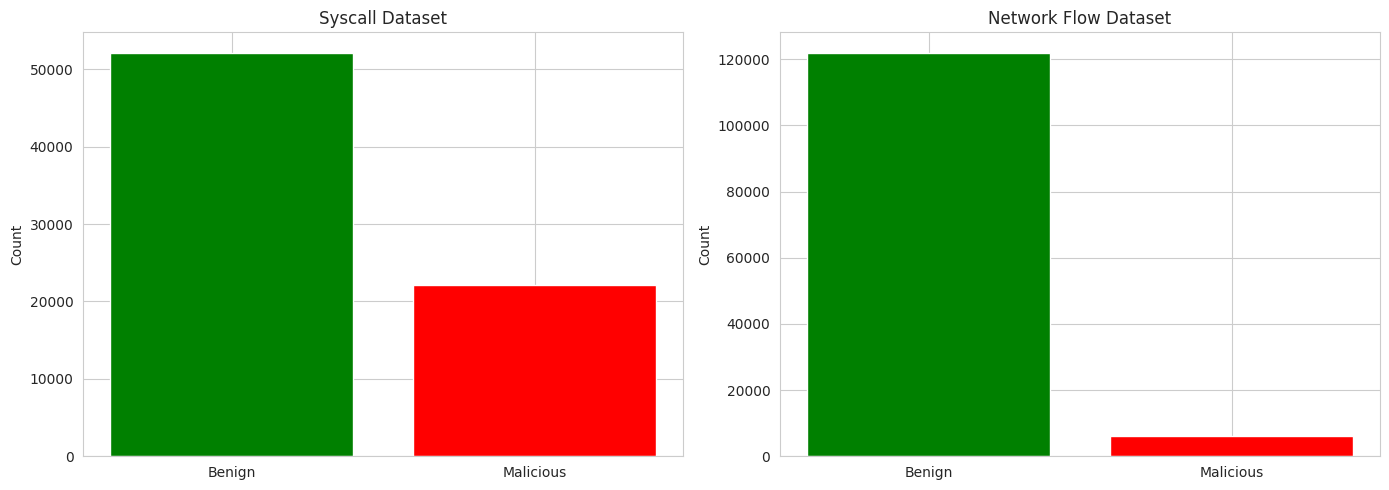

Preprocessing complete!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Syscall
syscall_counts = y_syscall.value_counts()
axes[0].bar(['Benign', 'Malicious'], [syscall_counts.get(0, 0), syscall_counts.get(1, 0)], color=['green', 'red'])
axes[0].set_title('Syscall Dataset')
axes[0].set_ylabel('Count')

# Network
flow_counts = y_flow.value_counts()
axes[1].bar(['Benign', 'Malicious'], [flow_counts.get(0, 0), flow_counts.get(1, 0)], color=['green', 'red'])
axes[1].set_title('Network Flow Dataset')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('output/label_distribution.png', dpi=150)
plt.show()

print("Preprocessing complete!")